In [ ]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
for REPO_ROOT in [cwd, *cwd.parents]:
    if (REPO_ROOT / 'utils.py').exists() and (REPO_ROOT / 'datapaths.py').exists():
        sys.path.insert(0, str(REPO_ROOT))
        os.chdir(REPO_ROOT)
        break
else:
    raise RuntimeError('Could not locate the repository root.')


In [1]:
from utils_activations import *
from utils import binarize
from binary_dimension import compute_histogram_jax, select_range, highest_prob_range , compute_histogram
from binary_dimension.utils import initial_gauss
from binary_dimension.optimization import DKL_Optimizer
from binary_dimension.distance_models import LinearDistanceModel , PolynomialDistanceModel
from utils import binarize,makefolder,emb_dims,depths

rcpsize = 20
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

def compute_BID(r,P,a_min=0.01,a_max=0.2,max_iter=1000,error=1e-10,lr=1.2,verbose=True):

  ### Select range for fitting
  _r,_P = select_range(r, P, a_min=a_min, a_max=a_max) 
  
  ### Initialization of parameters and optimizer
  distance_model = LinearDistanceModel()
  theta_init = initial_gauss(_r,_P)
  Dkl_optimizer = DKL_Optimizer(_r,_P, distance_model)

  ### Optimization
  theta_opt , log_DKL , Nit = Dkl_optimizer.optimize(theta_init,max_iter=max_iter,error=error,lr=lr)

  ### Computing P_model with optimizer parameters
  Pmod = distance_model.P_model(_r, theta_opt)

  if verbose: 
    print(f'Optimized parameters theta: {theta_opt}')
    print(f'Log D_KL at optimum: {log_DKL}')
    print(f'Number of iterations: {Nit}') 

  return theta_opt, log_DKL, Nit, _r, _P, Pmod

### Fit parameters 
a_min = 0.05 # min order of quantile of the distance distribution, between 0 and a_max
a_max = .2 # max order of quantile of the distance distribution, between a_min and 1
max_iter = 1000 # maximum number of optimization iterations, default value
error = 1e-10 # convergence error, default value
lr = 1.2 # default value 

model_name = 'deepseek'
layers = list(range(1, depths[model_name] + 1))
layer_vals = reduce_list_half_preserve_extremes(layers)
# layer_vals = reduce_list_half_preserve_extremes(layer_vals)
layer_vals = [layer_vals[len(layer_vals)//2]]
rel_depths = (np.array(layer_vals)) / (depths[model_name])

vars = ['act_A','sem','syn']


/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_files = 21
precision = 32
data_var = 'sem'
global_center_flag = 1
min_token_length = 3
avg_tokens = 1

n_tokens = min_token_length 
input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]

all_activations_A = collect_data(input_path_A, 
                                min_token_length, 
                                n_files,
                                model_name,
                                avg_tokens,
                                )

deepseek dtype: torch.bfloat16


Collect File: 100%|██████████| 21/21 [00:07<00:00,  2.83it/s]


all_hidden_states["layer_0"].shape=torch.Size([2018, 7168])
importing took 0.13895425001780193 m


In [5]:
previous_sem_centroids_A = []
previous_syn_centroids_A = []

d0s = np.zeros(shape=(3,len(layer_vals)))
d1s = np.zeros_like(d0s)
logKLs = np.zeros_like(d0s)

BID_folder0 = makefolder(base=f'results/BID/{model_name}/',create_folder=True)


enum_layer_id = -1
for layer in tqdm(layer_vals,desc='Layers'):
  enum_layer_id += 1

  act_A, syn_centroids_A, sem_centroids_A, global_center_A = preprocessing_sem_data(
      model_name=model_name,
      all_activations=all_activations_A, 
      layer=layer, 
      space_index='A',
      global_center_flag=global_center_flag,
      min_token_length=min_token_length,
      avg_tokens=avg_tokens,
      n_tokens=n_tokens,
  )
  # indices for batched_remove_centroid_projections
  idx = jnp.arange(act_A.shape[0], dtype=jnp.int32)

  # Remove syn-sem overlap within current layer
  syn_centroids_A = batched_remove_centroid_projections(
      syn_centroids_A,
      idx,
      sem_centroids_A,
  )
  for var_id,var in enumerate(vars):
    if var == 'sem':
      a = sem_centroids_A
    if var == 'act_A':
      a = act_A
    if var == 'syn':
      a = syn_centroids_A

    
    # syn_indices = np.loadtxt(syn_group_id_paths_for_sem_data['A'],dtype=int)
    # U, C = np.unique(syn_indices,return_counts=True)
    # most_common_syn_id = U[np.argmax(C)]
    # I = np.where(syn_indices == most_common_syn_id)[0]
    # a = a[I]

    r , P = compute_histogram_jax(binarize(a))
    # (theta_opt, log_DKL, Nit,
    # _r, _P, Pmod) = compute_BID(r=r,
    #                             P=P,
    #                             a_min=a_min,
    #                             a_max=a_max,
    #                             max_iter=max_iter,
    #                             error=error,
    #                             lr=lr,
    #                             verbose=False)
    # d0s[var_id,enum_layer_id] = theta_opt[0]
    # d1s[var_id,enum_layer_id] = theta_opt[1]
    # logKLs[var_id,enum_layer_id] = log_DKL

    BID_folder = makefolder(base=BID_folder0,
                            create_folder=True,
                            layer=layer,
                            )

    np.savetxt(
        os.path.join(BID_folder, f"histograms_{var}.txt"),
        np.column_stack((r, P)),
        fmt="%.18e",
    )
    # np.savetxt(
    #     os.path.join(BID_folder, f"histograms_{var}.txt"),
    #     np.column_stack((_r, _P, Pmod)),
    #     fmt="%.18e",
    # )

# for var_id,var in enumerate(vars):
#   np.savetxt(
#       os.path.join(BID_folder0, f"parameters_{var}.txt"),
#       np.column_stack((d0s[var_id], d1s[var_id], logKLs[var_id])),
#       fmt="%.18e",
#   )

    # # 2) Make current semantics orthogonal to all previous semantics
    # for prev_sem in previous_sem_centroids_A:
    #     sem_centroids_A = batched_remove_centroid_projections(
    #         sem_centroids_A,
    #         idx,
    #         prev_sem,
    #     )

    # # 3) Make current syntax orthogonal to all previous syntax
    # for prev_syn in previous_syn_centroids_A:
    #     syn_centroids_A = batched_remove_centroid_projections(
    #         syn_centroids_A,
    #         idx,
    #         prev_syn,
    #     )

    # # 5) Save *orthogonalized* centroids for next layers
    # previous_sem_centroids_A.append(sem_centroids_A)
    # previous_syn_centroids_A.append(syn_centroids_A)

Layers: 100%|██████████| 1/1 [00:20<00:00, 20.69s/it]


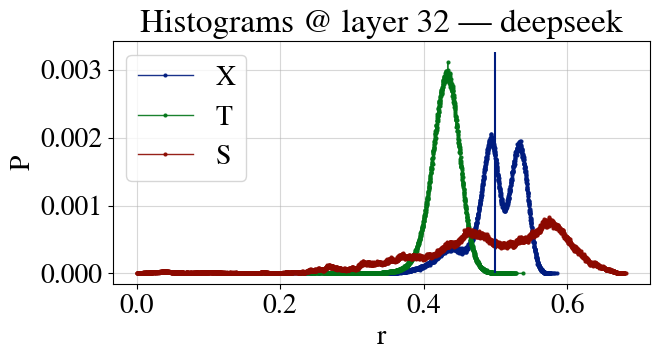

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

labels = {
    "act_A": "X",
    "sem": "T",
    "syn": "S",
}

# --- pick a layer from layer_vals ---
model_name = "deepseek"
layer = layer_vals[len(layer_vals) * 1//2]          # e.g. layer_vals[5]
vars_ = ["act_A", "sem", "syn"]
logy = False
# -----------------------------------

# Same folder logic you used when saving
BID_folder0 = makefolder(base=f"results/BID/{model_name}/", create_folder=False)
BID_folder  = makefolder(base=BID_folder0, create_folder=False, layer=layer)

plt.figure(figsize=(7, 4))

for var in vars_:
    path = os.path.join(BID_folder, f"histograms_{var}.txt")
    r, P = np.loadtxt(path).T
    plt.plot(r/emb_dims[model_name], P, marker="o", markersize=2, linewidth=1.0, alpha=0.9, label=labels[var])

plt.grid(True, alpha=0.5)
plt.xlabel("r")
plt.ylabel("P")
plt.title(f"Histograms @ layer {layer} — {model_name}")
if logy:
    plt.yscale("log")

plt.vlines(x=.5,ymin=P.min(),ymax=plt.ylim()[1])
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def _extract_layer(p: Path) -> int | None:
    """
    Try to infer the layer index from the path, e.g.
    .../layer=12/... or .../layer_12/... or .../layer12/...
    """
    s = str(p)
    m = re.search(r"(?:layer\s*=?\s*|layer[_-]?)(\d+)", s)
    if m:
        return int(m.group(1))

    # fallback: last integer in the path (less safe, but better than nothing)
    ms = re.findall(r"(\d+)", s)
    return int(ms[-1]) if ms else None


def _fig_to_pil(fig) -> Image.Image:
    """
    Convert a Matplotlib figure to a PIL Image in a Matplotlib-version-safe way.
    Uses buffer_rgba() when available; falls back to print_to_buffer().
    """
    fig.canvas.draw()

    # Preferred (works in modern matplotlib)
    try:
        rgba = np.asarray(fig.canvas.buffer_rgba())  # (H, W, 4) uint8
        rgb = rgba[..., :3].copy()
        return Image.fromarray(rgb)
    except Exception:
        pass

    # Fallback
    try:
        buf, (w, h) = fig.canvas.print_to_buffer()  # RGBA bytes
        rgba = np.frombuffer(buf, dtype=np.uint8).reshape(h, w, 4)
        rgb = rgba[..., :3].copy()
        return Image.fromarray(rgb)
    except Exception as e:
        raise RuntimeError(f"Could not convert figure to image: {e}") from e


def make_hist_gif(
    var: str,
    model_name: str,
    base_dir: str | Path = "results/BID",
    out_gif: str | Path | None = None,
    fps: float = 0.25,          # lower = slower (0.25 -> 4s per frame)
    logy: bool = False,
    dpi: int = 140,
    figsize: tuple[float, float] = (6.4, 4.0),
    hold_first: int = 0,        # extra repeats of first frame (optional)
    hold_last: int = 0,         # extra repeats of last frame (optional)
    repeat_each: int = 1,       # duplicate every frame N times (robust “slow down”)
) -> Path:
    """
    Loads all histograms_{var}.txt under results/BID/<model_name>/..., sorts by layer,
    renders one frame per layer, and exports a GIF with reliable timing via Pillow.
    """
    if fps <= 0:
        raise ValueError("fps must be > 0")
    if repeat_each < 1:
        raise ValueError("repeat_each must be >= 1")

    base_dir = Path(base_dir)
    root = base_dir / model_name
    files = sorted(root.glob(f"**/histograms_{var}.txt"))
    if not files:
        raise FileNotFoundError(f"No histograms_{var}.txt found under: {root.resolve()}")

    items: list[tuple[int, Path]] = []
    for f in files:
        layer = _extract_layer(f.parent)
        if layer is None:
            continue
        items.append((layer, f))

    if not items:
        raise RuntimeError(f"Found files but couldn't parse layer numbers under: {root.resolve()}")

    items.sort(key=lambda x: x[0])

    # Load once to fix global axes (avoids jumpy rescaling)
    curves: list[tuple[int, np.ndarray, np.ndarray]] = []
    for layer, f in items:
        arr = np.loadtxt(f)
        if arr.ndim != 2 or arr.shape[1] < 2:
            raise ValueError(f"Unexpected file format in {f} (expected 2 columns: r, P).")
        r = arr[:, 0]
        P = arr[:, 1]
        curves.append((layer, r, P))

    rmin = min(np.min(r) for _, r, _ in curves)
    rmax = max(np.max(r) for _, r, _ in curves)

    if logy:
        ppos = [P[P > 0] for _, _, P in curves]
        if not any(x.size > 0 for x in ppos):
            raise ValueError("logy=True but all P values are <= 0.")
        pmin = min(np.min(x) for x in ppos if x.size > 0)
        pmax = max(np.max(P) for _, _, P in curves)
    else:
        pmin = min(np.min(P) for _, _, P in curves)
        pmax = max(np.max(P) for _, _, P in curves)

    if out_gif is None:
        out_gif = root / f"{var}_histograms_progression_{model_name}.gif"
    out_gif = Path(out_gif)
    out_gif.parent.mkdir(parents=True, exist_ok=True)

    # Pillow duration is milliseconds per frame
    duration_ms = int(round(1000.0 / fps))

    frames: list[Image.Image] = []

    for i, (layer, r, P) in enumerate(curves):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        ax.plot(r, P, marker="o", markersize=2, linewidth=1.0, alpha=0.9)

        ax.set_xlim(rmin, rmax)
        if logy:
            ax.set_yscale("log")
            ax.set_ylim(max(pmin, 1e-300), pmax)
        else:
            ax.set_ylim(pmin, pmax)

        ax.grid(True, alpha=0.5)
        ax.set_xlabel("r")
        ax.set_ylabel("P")
        ax.set_title(f"{var} histogram — layer {layer}")

        fig.tight_layout()

        pil = _fig_to_pil(fig)
        plt.close(fig)

        # Quantize to palette mode for GIF size
        pil = pil.convert("P", palette=Image.Palette.ADAPTIVE)

        # Robust slow-down: duplicate each frame repeat_each times
        for _ in range(repeat_each):
            frames.append(pil)

    # Optional holds (adds extra time on first/last frame)
    if frames and hold_first > 0:
        frames = [frames[0]] * hold_first + frames
    if frames and hold_last > 0:
        frames = frames + [frames[-1]] * hold_last

    frames[0].save(
        out_gif,
        save_all=True,
        append_images=frames[1:],
        duration=duration_ms,
        loop=0,
        optimize=False,
    )

    return out_gif


if __name__ == "__main__":
    model_name = "deepseek"
    out = make_hist_gif(
        var="syn",
        model_name=model_name,
        fps=2,
        repeat_each=1,    # set to 2 or 3 if a viewer ignores delays
        hold_first=2,
        hold_last=4,
        logy=False,
    )
    print("Wrote:", out.resolve())


Wrote: /home/acevedo/syn-sem/results/BID/deepseek/syn_histograms_progression_deepseek.gif


NameError: name 'layer_vals' is not defined

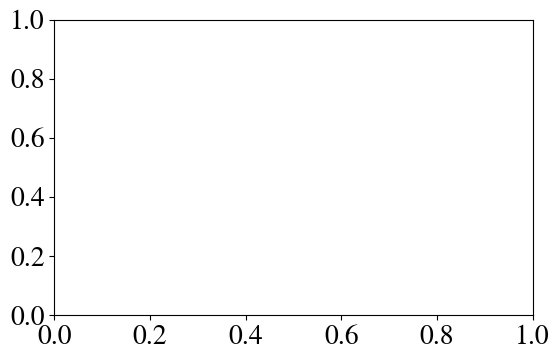

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(6, 4))

var = 'syn'

for enum_id,layer in enumerate(layer_vals[::3]):
  BID_folder = makefolder(base=BID_folder0, layer=layer)  # should reproduce same path you saved to

  data = np.loadtxt(os.path.join(BID_folder, f"histograms_{var}.txt"))
  _r   = data[:, 0]
  _P   = data[:, 1]
  # Pmod = data[:, 2]

  ax.plot(_r/emb_dims[model_name], _P, 'x', markersize=5, label=f'depth={layer/depths[model_name]:.2f}',color=colors[enum_id%len(colors)])
  # ax.plot(_r, Pmod,color='black')
  ax.set_xlabel('r/N')
  ax.set_ylabel('P(r)')
  ax.set_yscale('log')

  box = ax.get_position()
  ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()


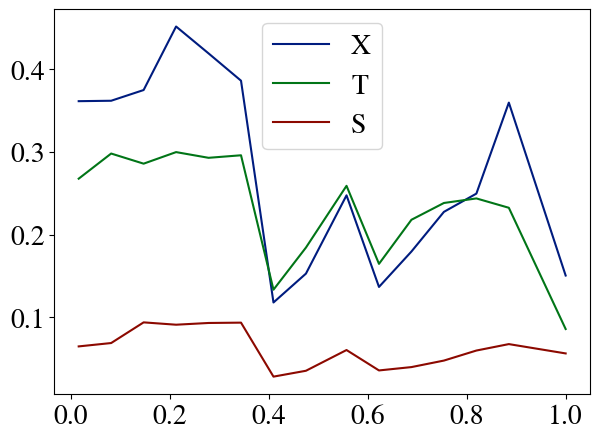

In [59]:
fig,ax = plt.subplots(1)
labels = {'act_A':'X','sem':'T','syn':'S'}
for var_id,var in enumerate(vars):
  d0s,d1s,logKLs = np.loadtxt(os.path.join(BID_folder0, f"parameters_{var}.txt"),unpack=True)
  ax.plot(rel_depths, d0s/emb_dims[model_name], label=f'{labels[var]}')

ax.legend()

fig.show()

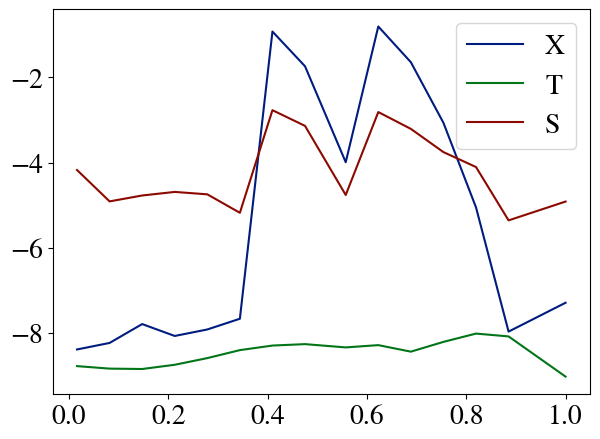

In [47]:
fig,ax = plt.subplots(1)
labels = {'act_A':'X','sem':'T','syn':'S'}
for var_id,var in enumerate(vars):
  d0s,d1s,logKLs = np.loadtxt(os.path.join(BID_folder0, f"parameters_{var}.txt"),unpack=True)
  ax.plot(rel_depths, logKLs, label=f'{labels[var]}')

ax.legend()

fig.show()